# New Experiments using Datasetv2

- First run, no imputation, no standardization. 
- coarse grid search

In [1]:
import importlib
import feature_engineering as fe_module
import model as model_module
importlib.reload(fe_module)
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_v2/pooled_CN.csv", "CN"),
    ("datasets/Dataset_v2/pooled_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.05],
    'subsample': [0.4, 0.6, 0.8],
    'colsample_bytree': [0.4, 0.6, 0.8],
}

results_dir = "experiments/experiment_0.1/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp0_1_results = {}
exp0_1_models = {}    # { key: (model, cols, summary) }

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Grid search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols, summary = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_0.1",
            cv_method='skf',
            n_jobs=8,
            model_base_name=base,
            save_artifacts=True,
        )
        key = f"{base}_{prog}"
        exp0_1_results[key] = pd.read_csv(csv_out)
        exp0_1_models[key]  = (model, cols, summary)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Grid search: pooled_CN (CN) — 12092 samples ===
Using StratifiedKFold with n_splits=5
Grid search: 243 hyperparameter combinations (n_jobs=8)


SKF grid search: 100%|██████████| 243/243 [05:00<00:00,  1.24s/combo]


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94      1984
           1       0.66      0.87      0.75       435

    accuracy                           0.90      2419
   macro avg       0.82      0.89      0.84      2419
weighted avg       0.91      0.90      0.90      2419


ROC AUC Score: 0.9441
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.897 (CI: 0.886, 0.909) range=0.023
- Precision (macro): 0.817 (CI: 0.796, 0.836) range=0.040
- Recall (macro): 0.887 (CI: 0.871, 0.903) range=0.033
- F1 (macro): 0.844 (CI: 0.826, 0.861) range=0.035
- ROC AUC: 0.944 (CI: 0.930, 0.956) range=0.026

Saved artifacts:
- Model:   experiments/experiment_0.1/pooled_CN_model_CN.pkl
- Scaler:  experiments/experiment_0.1/pooled_CN_scaler_CN.pkl
- Imputer: experiments/experiment_0.1/pooled_CN_imputer_CN.pkl
- Report:  experiments/experiment_0.1/poole

SKF grid search: 100%|██████████| 243/243 [02:53<00:00,  1.40combo/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       280
           1       0.83      0.79      0.81       299

    accuracy                           0.81       579
   macro avg       0.81      0.81      0.81       579
weighted avg       0.81      0.81      0.81       579


ROC AUC Score: 0.8824
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.810 (CI: 0.777, 0.841) range=0.064
- Precision (macro): 0.810 (CI: 0.777, 0.842) range=0.065
- Recall (macro): 0.811 (CI: 0.778, 0.843) range=0.065
- F1 (macro): 0.810 (CI: 0.776, 0.841) range=0.065
- ROC AUC: 0.882 (CI: 0.854, 0.909) range=0.055

Saved artifacts:
- Model:   experiments/experiment_0.1/pooled_MCI_AD_model_AD.pkl
- Scaler:  experiments/experiment_0.1/pooled_MCI_AD_scaler_AD.pkl
- Imputer: experiments/experiment_0.1/pooled_MCI_AD_imputer_AD.pkl
- Report:  experiments/experime


Visualizations — pooled_CN_CN


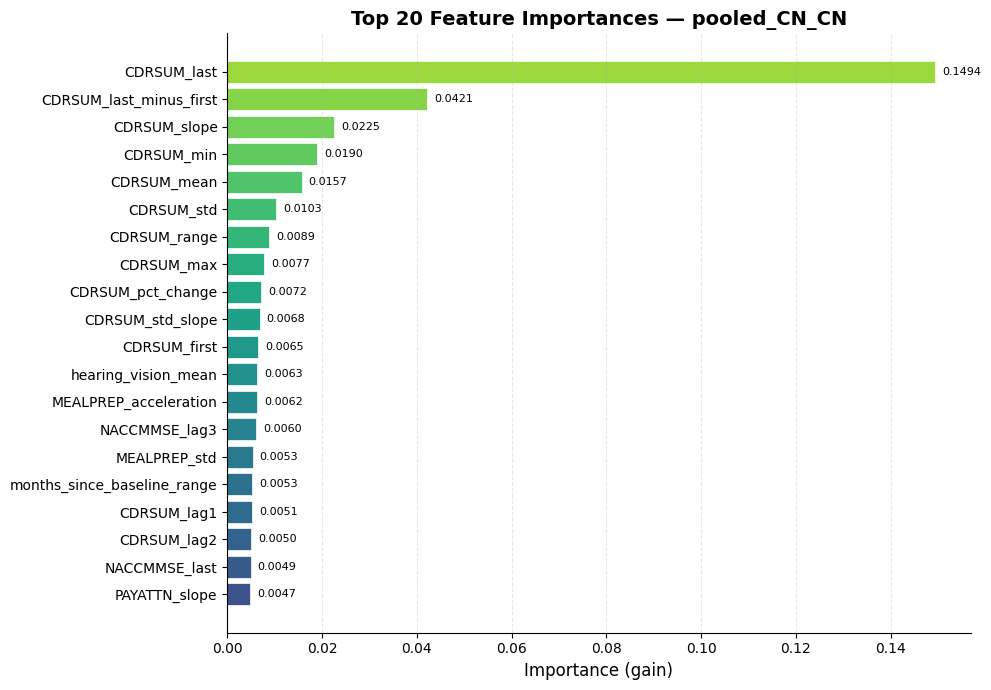

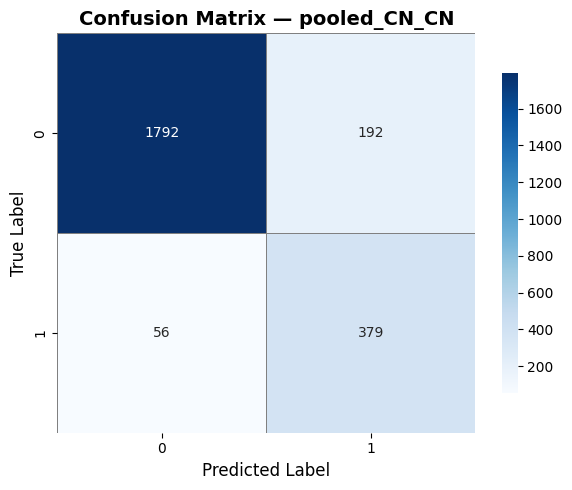

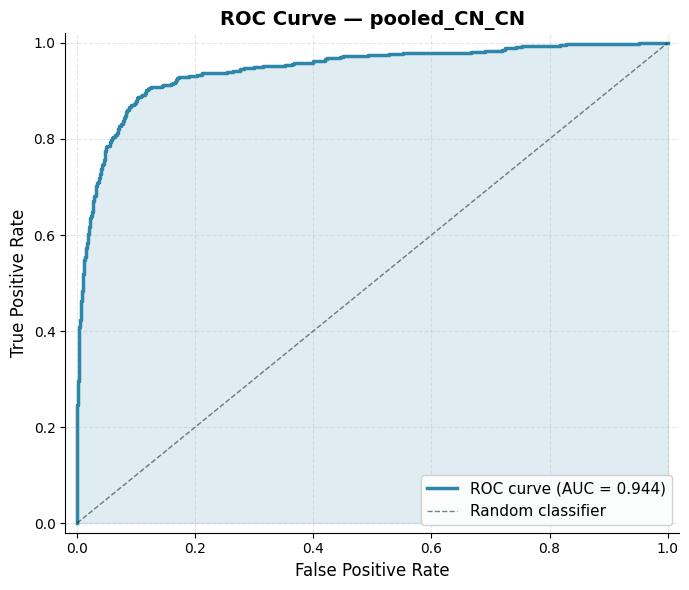


Visualizations — pooled_MCI_AD_AD


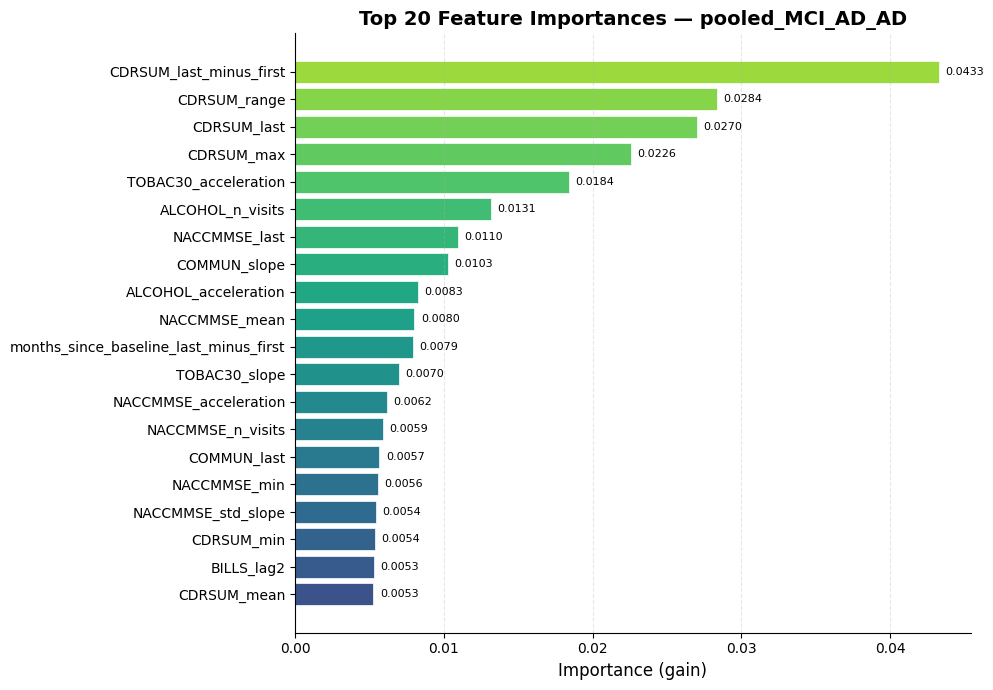

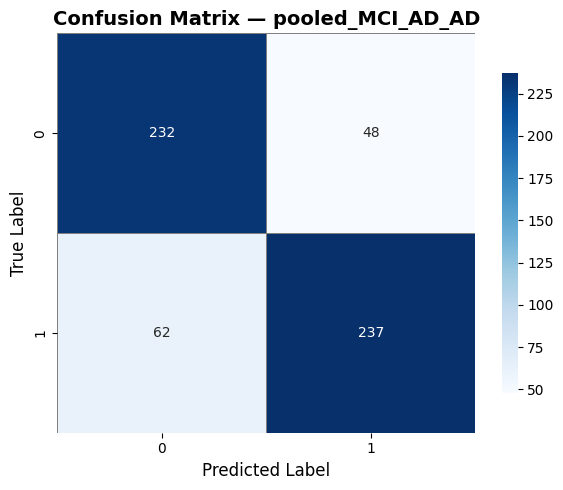

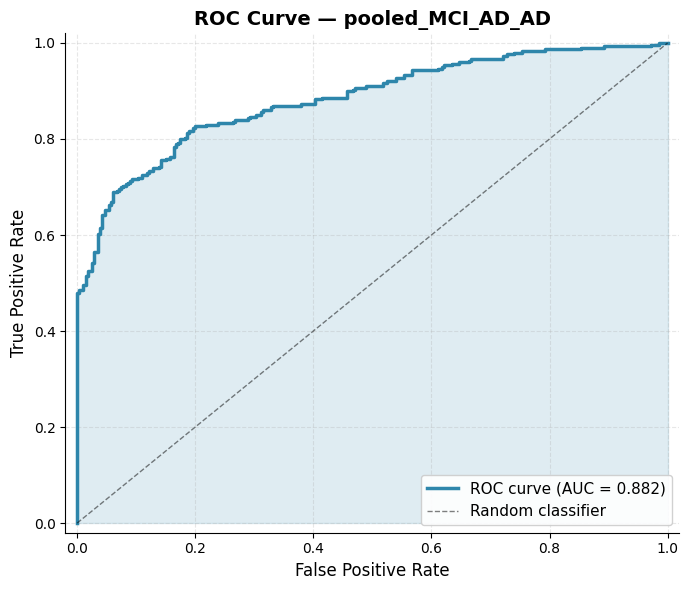

In [2]:

import importlib
import visualization as viz_module
importlib.reload(viz_module)
from visualization import plot_feature_importance, plot_confusion_mat, plot_roc
import os

charts_dir = "experiments/experiment_0.1/charts"
os.makedirs(charts_dir, exist_ok=True)

for key, (model, cols, summary) in exp0_1_models.items():
    print(f"\n{'='*60}")
    print(f"Visualizations — {key}")
    print(f"{'='*60}")

    # Feature importance
    plot_feature_importance(
        model.feature_importances_,
        cols,
        top_n=20,
        title=f"Top 20 Feature Importances — {key}",
        save_path=os.path.join(charts_dir, f"{key}_feature_importance.png"),
    )

    # Confusion matrix
    plot_confusion_mat(
        summary["y_true"],
        summary["y_pred"],
        title=f"Confusion Matrix — {key}",
        save_path=os.path.join(charts_dir, f"{key}_confusion_matrix.png"),
    )

    # ROC curve
    plot_roc(
        summary["y_true"],
        summary["y_proba"],
        title=f"ROC Curve — {key}",
        save_path=os.path.join(charts_dir, f"{key}_roc_curve.png"),
    )


- 06-03-26
- loocv with same params
- loocv results not finishing: takes too long
- cell below ran as a smoke test for making sure removing loocv didn't break any code. 

In [ ]:
import importlib
import feature_engineering as fe_module
import model as model_module
importlib.reload(fe_module)
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_v2/pooled_CN.csv", "CN"),
    ("datasets/Dataset_v2/pooled_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.05],
    'subsample': [0.4, 0.6, 0.8],
    'colsample_bytree': [0.4, 0.6, 0.8],
}

results_dir = "experiments/experiment_0.2/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp0_2_results = {}
exp0_2_models = {}    # { key: (model, cols, summary) }

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Grid search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols, summary = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_test",
            n_jobs=10,
            model_base_name=base,
            save_artifacts=True,
        )
        key = f"{base}_{prog}"
        exp0_2_results[key] = pd.read_csv(csv_out)
        exp0_2_models[key]  = (model, cols, summary)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Grid search: pooled_CN (CN) — 12092 samples ===
Using StratifiedKFold with n_splits=5
Grid search: 243 hyperparameter combinations (n_jobs=1)


SKF grid search: 100%|██████████| 243/243 [28:06<00:00,  6.94s/combo]


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94      1984
           1       0.66      0.87      0.75       435

    accuracy                           0.90      2419
   macro avg       0.82      0.89      0.84      2419
weighted avg       0.91      0.90      0.90      2419


ROC AUC Score: 0.9441
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.897 (CI: 0.886, 0.909) range=0.023
- Precision (macro): 0.817 (CI: 0.796, 0.836) range=0.040
- Recall (macro): 0.887 (CI: 0.871, 0.903) range=0.033
- F1 (macro): 0.844 (CI: 0.826, 0.861) range=0.035
- ROC AUC: 0.944 (CI: 0.930, 0.956) range=0.026

Saved artifacts:
- Model:   experiments/experiment_test/pooled_CN_model_CN.pkl
- Scaler:  experiments/experiment_test/pooled_CN_scaler_CN.pkl
- Imputer: experiments/experiment_test/pooled_CN_imputer_CN.pkl
- Report:  experiments/experiment_test/p

SKF grid search:   1%|          | 2/243 [00:01<03:38,  1.10combo/s]


KeyboardInterrupt: 